Mounted at /content/drive
Save folder: /content/drive/MyDrive
Shape: (9700, 17)


,id,firstname,lastname,phonenumber,email,gender,maritalstatus,street,city,state,postalcode,productcode,price,discount,sku,transactionamount,transactiondate
0,1,Danielle,Johnson,87463172130,danielle.johnson@gmail.com,M,Divorced,32181 Johnson Course Apt. 389,New Jamesside,Nebraska,29394,PRD-5506,1228.23,0.2,SKU23434,67508.30,2024-05-09
1,2,Bridget,Pacheco,98318820640,bridget.pacheco@gmail.com,Unknown,Single,65423 Garcia Light,West Melanieview,Arizona,96148,PRD-1488,473.01,0.2,SKU76237,60002.88,2024-05-17
2,3,Amanda,Dudley,84105291900,amanda.dudley@yahoo.com,Unknown,single,84959 Janet Cape Apt. 413,South Joshuastad,Hawaii,49021,PRD-8359,2948.38,0.1,SKU30926,69663.01,2024-02-26
3,4,Jason,Adams,74613648540,jason.adams@outlook.com,male,single,283 Steven Groves,Lake Mark,Wyoming,7832,PRD-6514,515.54,0.0,SKU22676,35577.43,2023-11-20
4,5,Lydia,Trujillo,74772785770,lydia.trujillo@outlook.com,M,Divorced,1395 Diana Locks Suite 242,Lake Anna,Kentucky,98413,PRD-8527,2683.46,0.0,SKU20328,54980.08,2024-08-23


Daily aggregated shape: (731, 3)


,sales_date,units_sold,sales_amount
0,2023-05-27,12,0.041708
1,2023-05-28,10,0.051619
2,2023-05-29,18,0.087004
3,2023-05-30,11,0.046202
4,2023-05-31,10,0.069156


✅ Lag & rolling features created


,sales_date,units_sold,sales_amount,lag_1,lag_7,rolling_7
0,2023-06-03,15,0.076012,0.101134,0.041708,0.068875
1,2023-06-04,15,0.072953,0.076012,0.051619,0.071923
2,2023-06-05,16,0.093677,0.072953,0.087004,0.072876
3,2023-06-06,17,0.089329,0.093677,0.046202,0.079037
4,2023-06-07,19,0.119380,0.089329,0.069156,0.086212


Baseline Naive Forecast -> MAE: 0.2643, sMAPE: 67.43%


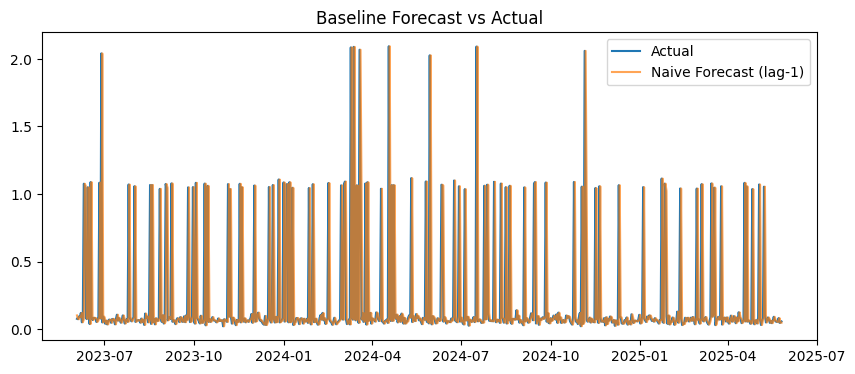

Saved transformed dataset to: /content/drive/MyDrive/transactions_transformed.csv
Saved daily aggregated dataset to: /content/drive/MyDrive/daily_sales_for_modeling.csv
Notebook 4 complete ✅ — EDA, aggregation, and baseline forecast finished!


In [ ]:
# =========================
# Part 1 — Setup
# =========================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from IPython.display import display

try:
    from google.colab import drive
except Exception:
    drive = None

# =========================
# Part 2 — Mount Google Drive
# =========================
mount_drive = True
if mount_drive and drive is not None:
    drive.mount('/content/drive', force_remount=False)
    DRIVE_BASE = '/content/drive/MyDrive'
else:
    DRIVE_BASE = '/content'

os.makedirs(DRIVE_BASE, exist_ok=True)
print("Save folder:", DRIVE_BASE)

# =========================
# Part 3 — Load cleaned data
# =========================
clean_path = os.path.join(DRIVE_BASE, 'clean_sales.csv')
df = pd.read_csv(clean_path, low_memory=False, parse_dates=[c for c in pd.read_csv(clean_path, nrows=1).columns if 'date' in c.lower()])
print("Shape:", df.shape)
display(df.head())

# =========================
# Part 4 — Standard features
# =========================
amt_col = 'transactionamount' if 'transactionamount' in df.columns else ('unitprice' if 'unitprice' in df.columns else None)
disc_col = 'discount' if 'discount' in df.columns else None
date_col = [c for c in df.columns if 'date' in c.lower()][0]

df['final_amount'] = df[amt_col] - (df[disc_col] if disc_col in df.columns else 0)
df['discount_rate'] = np.where(df[amt_col]>0, (df[disc_col].fillna(0))/df[amt_col], 0)
df[date_col] = pd.to_datetime(df[date_col])
df['month'] = df[date_col].dt.month
df['day'] = df[date_col].dt.day
df['dow'] = df[date_col].dt.dayofweek

# =========================
# Part 5 — Encode categorical variables
# =========================
for c in ['gender', 'maritalstatus']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower().replace({'nan':'unknown'})

if 'gender' in df.columns:
    df['gender_code'] = df['gender'].map({'male':1,'female':0,'unknown':-1}).fillna(-1)
if 'maritalstatus' in df.columns:
    df['marital_code'] = df['maritalstatus'].map({'single':0,'married':1,'divorced':2,'unknown':-1}).fillna(-1)

if 'productcode' in df.columns:
    df = pd.get_dummies(df, columns=['productcode'], prefix='prod', drop_first=True)

# =========================
# Part 6 — Normalize numeric features
# =========================
scaler = MinMaxScaler()
numeric_cols = [c for c in ['price', 'transactionamount', 'discount', 'final_amount', 'discount_rate'] if c in df.columns]
if len(numeric_cols) > 0:
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# =========================
# Part 7 — Aggregate to daily sales
# =========================
if 'productcode' in df.columns:
    daily = (df.groupby([date_col,'productcode'])
               .agg(units_sold=('quantity','sum') if 'quantity' in df.columns else ('final_amount','count'),
                    sales_amount=('final_amount','sum'))
               .reset_index()
               .rename(columns={date_col:'sales_date'}))
else:
    daily = (df.groupby(date_col)
               .agg(units_sold=('quantity','sum') if 'quantity' in df.columns else ('final_amount','count'),
                    sales_amount=('final_amount','sum'))
               .reset_index()
               .rename(columns={date_col:'sales_date'}))

daily['sales_date'] = pd.to_datetime(daily['sales_date'])
daily = daily.sort_values('sales_date').reset_index(drop=True)
print("Daily aggregated shape:", daily.shape)
display(daily.head())

# =========================
# Part 8 — Create lag & rolling features
# =========================
daily["lag_1"] = daily["sales_amount"].shift(1)
daily["lag_7"] = daily["sales_amount"].shift(7)
daily["rolling_7"] = daily["sales_amount"].rolling(7).mean()
daily_sales = daily.dropna().reset_index(drop=True)
print("Lag & rolling features created")
display(daily_sales.head())

# =========================
# Part 9 — Baseline forecast
# =========================
y_true = daily_sales["sales_amount"]
y_pred = daily_sales["lag_1"]

mae = mean_absolute_error(y_true, y_pred)
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

print(f"Baseline Naive Forecast -> MAE: {mae:.4f}, sMAPE: {smape:.2f}%")

plt.figure(figsize=(10,4))
plt.plot(daily_sales["sales_date"], y_true, label="Actual")
plt.plot(daily_sales["sales_date"], y_pred, label="Naive Forecast (lag-1)", alpha=0.7)
plt.legend()
plt.title("Baseline Forecast vs Actual")
plt.show()

# =========================
# Part 10 — Save transformed datasets
# =========================
transformed_path = os.path.join(DRIVE_BASE, 'transactions_transformed.csv')
daily_path = os.path.join(DRIVE_BASE, 'daily_sales_for_modeling.csv')

df.to_csv(transformed_path, index=False)
daily.to_csv(daily_path, index=False)

print("Saved transformed dataset to:", transformed_path)
print("Saved daily aggregated dataset to:", daily_path)

# =========================
# Part 11 — Quick summary
# =========================
print("Notebook 4 complete — EDA, aggregation, and baseline forecast finished!")
